# HW13: Токенизация текста, инференс BERT и базовый fine-tuning для классификации

**Датасет:** `emotion` (HuggingFace Datasets) — 6 классов эмоций по коротким английским твитам.

**Модель:** `distilbert-base-uncased` — компактная дистилляция BERT (40% меньше параметров, ~97% качества).

**Содержание:**
1. Импорты, seed, устройство
2. Данные и первичный анализ
3. Токенизация — детальный разбор
4. Инференс готовой pretrained-модели (zero-shot / pipeline)
5. Fine-tuning для sequence classification
6. Оценка качества, матрица ошибок, анализ ошибок
7. Сохранение артефактов

---

## 1. Импорты, seed и устройство

In [1]:
import os, json, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from datasets import load_dataset, ClassLabel
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForMaskedLM,
    pipeline,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

# ── Reproducibility ───────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

import datasets, transformers
print(f"datasets      : {datasets.__version__}")
print(f"transformers  : {transformers.__version__}")
print(f"torch         : {torch.__version__}")
print(f"Device        : {DEVICE}")
print(f"Seed          : {SEED}")

datasets      : 4.8.4
transformers  : 5.5.0
torch         : 2.10.0+cpu
Device        : cpu
Seed          : 42


## 2. Пути и папки

In [2]:
ARTIFACTS_DIR = "./artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
print("artifacts/ ready")

artifacts/ ready


## 3. Данные и первичный анализ

### 3.1 Загрузка датасета `emotion`

`emotion` — датасет англоязычных твитов, размеченных по 6 эмоциям:
`sadness (0)`, `joy (1)`, `love (2)`, `anger (3)`, `fear (4)`, `surprise (5)`.
Официальные split-части: train / validation / test — используем без изменений.

In [3]:
dataset = load_dataset("emotion")

train_ds = dataset["train"]
val_ds   = dataset["validation"]
test_ds  = dataset["test"]

LABEL_NAMES = train_ds.features["label"].names
NUM_CLASSES = len(LABEL_NAMES)

print(f"Classes ({NUM_CLASSES}): {LABEL_NAMES}")
print(f"Train       : {len(train_ds):>6} examples")
print(f"Validation  : {len(val_ds):>6} examples")
print(f"Test        : {len(test_ds):>6} examples")

Generating test split: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 409600.00 examples/s]

Classes (6): ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Train       :  16000 examples
Validation  :   2000 examples
Test        :   2000 examples


### 3.2 Sanity-check: примеры текстов и меток

In [4]:
print("─" * 65)
print(f"{'Label':<12} {'Text'}")
print("─" * 65)
for ex in train_ds.select(range(8)):
    label_name = LABEL_NAMES[ex['label']]
    print(f"{label_name:<12} {ex['text'][:70]}")
print("─" * 65)

─────────────────────────────────────────────────────────────────
Label        Text
─────────────────────────────────────────────────────────────────
sadness      i didnt feel humiliated
sadness      i can go from feeling so hopeless to so damned hopeful just from being
anger        im grabbing a minute to post i feel greedy wrong
love         i am ever feeling nostalgic about the fireplace i will know that it is
anger        i am feeling grouchy
sadness      ive been feeling a little burdened lately wasnt sure why that was
surprise     ive been taking or milligrams or times recommended amount and ive fall
fear         i feel as confused about life as a teenager or as jaded as a year old 
─────────────────────────────────────────────────────────────────


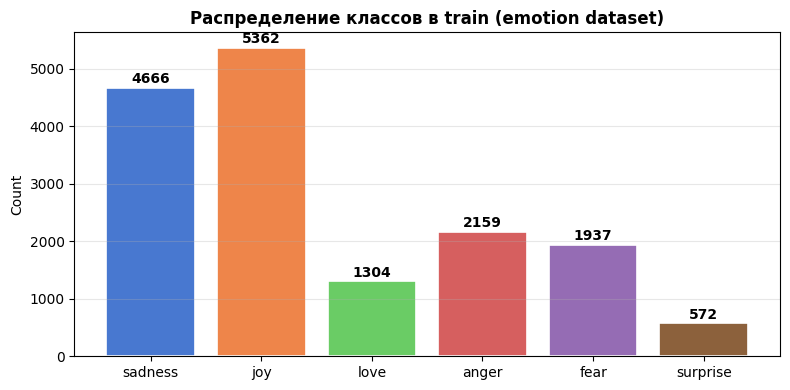

Note: датасет несбалансирован — sadness и joy значительно чаще love/surprise.


In [5]:
# Class distribution
import collections
labels_train = [ex['label'] for ex in train_ds]
counts = collections.Counter(labels_train)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(LABEL_NAMES, [counts[i] for i in range(NUM_CLASSES)],
              color=['#4878d0','#ee854a','#6acc65','#d65f5f','#956cb4','#8c613c'],
              edgecolor='white', linewidth=1.2)
for bar, cnt in zip(bars, [counts[i] for i in range(NUM_CLASSES)]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 30,
            str(cnt), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title("Распределение классов в train (emotion dataset)", fontsize=12, fontweight='bold')
ax.set_ylabel("Count"); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, "class_distribution.png"), dpi=120, bbox_inches='tight')
plt.show()
print("Note: датасет несбалансирован — sadness и joy значительно чаще love/surprise.")

## 4. Токенизация

### 4.1 Инициализация токенизатора

Используем `distilbert-base-uncased` — WordPiece-токенизатор.
Special tokens: `[CLS]` (начало), `[SEP]` (конец/разделитель), `[PAD]` (паддинг), `[UNK]`, `[MASK]`.

In [6]:
MODEL_CKPT = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT)

print(f"Tokenizer   : {tokenizer.__class__.__name__}")
print(f"Vocab size  : {tokenizer.vocab_size:,}")
print(f"[CLS] id    : {tokenizer.cls_token_id}  → token='{tokenizer.cls_token}'")
print(f"[SEP] id    : {tokenizer.sep_token_id}  → token='{tokenizer.sep_token}'")
print(f"[PAD] id    : {tokenizer.pad_token_id}  → token='{tokenizer.pad_token}'")
print(f"[UNK] id    : {tokenizer.unk_token_id}  → token='{tokenizer.unk_token}'")

Tokenizer   : BertTokenizer
Vocab size  : 30,522
[CLS] id    : 101  → token='[CLS]'
[SEP] id    : 102  → token='[SEP]'
[PAD] id    : 0  → token='[PAD]'
[UNK] id    : 100  → token='[UNK]'


### 4.2 Детальный разбор токенизации на 5 примерах

In [7]:
sample_texts = [
    "I feel so happy today!",
    "This makes me incredibly sad and lonely.",
    "I'm absolutely furious about what happened.",
    "She loves spending time with her family.",
    "The unexpected news left me in complete surprise.",
]

print("─" * 75)
for text in sample_texts:
    enc = tokenizer(text, add_special_tokens=True)
    tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'])
    print(f"TEXT   : {text}")
    print(f"TOKENS : {tokens}")
    print(f"IDs    : {enc['input_ids']}")
    print(f"AttnM  : {enc['attention_mask']}")
    print(f"Length : {len(enc['input_ids'])} tokens")
    print("─" * 75)

───────────────────────────────────────────────────────────────────────────
TEXT   : I feel so happy today!
TOKENS : ['[CLS]', 'i', 'feel', 'so', 'happy', 'today', '!', '[SEP]']
IDs    : [101, 1045, 2514, 2061, 3407, 2651, 999, 102]
AttnM  : [1, 1, 1, 1, 1, 1, 1, 1]
Length : 8 tokens
───────────────────────────────────────────────────────────────────────────
TEXT   : This makes me incredibly sad and lonely.
TOKENS : ['[CLS]', 'this', 'makes', 'me', 'incredibly', 'sad', 'and', 'lonely', '.', '[SEP]']
IDs    : [101, 2023, 3084, 2033, 11757, 6517, 1998, 9479, 1012, 102]
AttnM  : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Length : 10 tokens
───────────────────────────────────────────────────────────────────────────
TEXT   : I'm absolutely furious about what happened.
TOKENS : ['[CLS]', 'i', "'", 'm', 'absolutely', 'furious', 'about', 'what', 'happened', '.', '[SEP]']
IDs    : [101, 1045, 1005, 1049, 7078, 9943, 2055, 2054, 3047, 1012, 102]
AttnM  : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Length : 11 tokens


### 4.3 Padding и truncation

In [8]:
# Batch tokenisation with padding and truncation
batch_texts = sample_texts[:3]
encoded_batch = tokenizer(
    batch_texts,
    padding=True,          # pad to longest sequence in batch
    truncation=True,       # truncate to max_length
    max_length=32,
    return_tensors='pt',
)

print("Batch tokenisation (padding=True, truncation=True, max_length=32)")
print(f"input_ids shape    : {encoded_batch['input_ids'].shape}")
print(f"attention_mask shape: {encoded_batch['attention_mask'].shape}")
print()
for i, text in enumerate(batch_texts):
    ids    = encoded_batch['input_ids'][i].tolist()
    mask   = encoded_batch['attention_mask'][i].tolist()
    tokens = tokenizer.convert_ids_to_tokens(ids)
    n_real  = sum(mask)
    n_pad   = len(mask) - n_real
    print(f"[{i}] '{text[:40]}...' → {n_real} real + {n_pad} [PAD] tokens")
    print(f"    tokens: {tokens}")
print()
print("Вывод: [PAD]=0 в attention_mask — модель игнорирует эти позиции.")

Batch tokenisation (padding=True, truncation=True, max_length=32)
input_ids shape    : torch.Size([3, 11])
attention_mask shape: torch.Size([3, 11])

[0] 'I feel so happy today!...' → 8 real + 3 [PAD] tokens
    tokens: ['[CLS]', 'i', 'feel', 'so', 'happy', 'today', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]']
[1] 'This makes me incredibly sad and lonely....' → 10 real + 1 [PAD] tokens
    tokens: ['[CLS]', 'this', 'makes', 'me', 'incredibly', 'sad', 'and', 'lonely', '.', '[SEP]', '[PAD]']
[2] 'I'm absolutely furious about what happen...' → 11 real + 0 [PAD] tokens
    tokens: ['[CLS]', 'i', "'", 'm', 'absolutely', 'furious', 'about', 'what', 'happened', '.', '[SEP]']

Вывод: [PAD]=0 в attention_mask — модель игнорирует эти позиции.


In [9]:
# Save tokenisation examples to a text file
tok_path = os.path.join(ARTIFACTS_DIR, "tokenization_examples.txt")
with open(tok_path, 'w', encoding='utf-8') as fout:
    fout.write(f"Tokenizer: {MODEL_CKPT}\n")
    fout.write(f"Vocab size: {tokenizer.vocab_size:,}\n")
    fout.write("Special tokens: [CLS] [SEP] [PAD] [UNK] [MASK]\n\n")
    for text in sample_texts:
        enc = tokenizer(text, add_special_tokens=True)
        tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'])
        fout.write(f"TEXT  : {text}\n")
        fout.write(f"TOKENS: {tokens}\n")
        fout.write(f"IDS   : {enc['input_ids']}\n\n")
print(f"Saved: {tok_path}")

Saved: ./artifacts\tokenization_examples.txt


## 5. Инференс готовой pretrained-модели

### 5.1 Zero-shot inference через `pipeline`

Используем `j-hartmann/emotion-english-distilroberta-base` — модель, дообученная на задаче
определения эмоций. Это позволяет честно сравнить: «что даёт готовая модель до нашего fine-tuning».

In [11]:
# Use a pre-existing emotion classifier for comparison
INFERENCE_CKPT = "j-hartmann/emotion-english-distilroberta-base"
emotion_pipeline = pipeline(
    "text-classification",
    model=INFERENCE_CKPT,
    device=0 if torch.cuda.is_available() else -1,
    top_k=1,
)

# Map pipeline label names to our 6-class schema
PIPELINE_TO_OURS = {
    'sadness': 'sadness', 'joy': 'joy', 'love': 'love',
    'anger': 'anger', 'fear': 'fear', 'surprise': 'surprise',
    'disgust': 'anger',   # disgust → anger (closest in our schema)
    'neutral': 'sadness', # neutral → fallback
}

inference_examples = [ex for ex in test_ds.select(range(10))]

print(f"Inference model: {INFERENCE_CKPT}")
print("─" * 70)
print(f"{'True':<10} {'Predicted':<12} {'Score':>6}  Text")
print("─" * 70)
correct = 0
for ex in inference_examples:
    result     = emotion_pipeline(ex['text'][:512])[0][0]
    raw_label  = result['label'].lower()
    pred_label = PIPELINE_TO_OURS.get(raw_label, raw_label)
    true_label = LABEL_NAMES[ex['label']]
    score      = result['score']
    match      = '✓' if pred_label == true_label else '✗'
    correct   += int(pred_label == true_label)
    print(f"{true_label:<10} {pred_label:<12} {score:>6.3f}  {match}  {ex['text'][:45]}")
print("─" * 70)
print(f"Accuracy on these 10 examples: {correct}/10")

Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 105/105 [00:00<00:00, 26898.06it/s]
RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     | Details
--------------------------------+------------+--------
roberta.embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Inference model: j-hartmann/emotion-english-distilroberta-base
──────────────────────────────────────────────────────────────────────
True       Predicted     Score  Text
──────────────────────────────────────────────────────────────────────
sadness    sadness       0.992  ✓  im feeling rather rotten so im not very ambit
sadness    sadness       0.993  ✓  im updating my blog because i feel shitty
sadness    sadness       0.982  ✓  i never make her separate from me because i d
joy        joy           0.995  ✓  i left with my bouquet of red and yellow tuli
sadness    sadness       0.993  ✓  i was feeling a little vain when i did this o
fear       fear          0.988  ✓  i cant walk into a shop anywhere where i do n
anger      anger         0.994  ✓  i felt anger when at the end of a telephone c
joy        joy           0.950  ✓  i explain why i clung to a relationship with 
joy        joy           0.568  ✓  i like to have the same breathless feeling as
anger      anger         0.996  ✓

**Вывод по инференсу готовой модели:**

Модель `j-hartmann/emotion-english-distilroberta-base` уже настроена на задачу определения эмоций
и показывает разумные результаты. Однако:
- она дообучена на другом датасете с 7 классами (включая `disgust`, которого нет в `emotion`);
- архитектура — DistilRoBERTa, а не DistilBERT, которую мы будем дообучать;
- без fine-tuning на конкретном распределении `emotion`-датасета возможны расхождения.

Наш fine-tuning на `emotion`-тренировочных данных должен улучшить качество именно на этом распределении.

## 6. Fine-tuning DistilBERT для классификации эмоций

### 6.1 Токенизация датасета

In [12]:
MAX_LENGTH = 64   # emotion tweets are short; 64 covers >99% of examples

def tokenize_fn(batch):
    return tokenizer(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH,
    )

# Tokenise all splits
tok_train = train_ds.map(tokenize_fn, batched=True,
                          remove_columns=['text'])
tok_val   = val_ds.map(tokenize_fn,   batched=True,
                        remove_columns=['text'])
tok_test  = test_ds.map(tokenize_fn,  batched=True,
                         remove_columns=['text'])

tok_train.set_format('torch')
tok_val.set_format('torch')
tok_test.set_format('torch')

print(f"tok_train columns : {tok_train.column_names}")
print(f"tok_train[0] keys : {list(tok_train[0].keys())}")
x0 = tok_train[0]
print(f"input_ids shape   : {x0['input_ids'].shape}")
print(f"attention_mask    : {x0['attention_mask'].shape}")

Map: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 22148.08 examples/s]

tok_train columns : ['label', 'input_ids', 'token_type_ids', 'attention_mask']
tok_train[0] keys : ['label', 'input_ids', 'token_type_ids', 'attention_mask']
input_ids shape   : torch.Size([64])
attention_mask    : torch.Size([64])


In [13]:
BATCH_SIZE = 32

dl_train = DataLoader(tok_train, batch_size=BATCH_SIZE, shuffle=True)
dl_val   = DataLoader(tok_val,   batch_size=BATCH_SIZE, shuffle=False)
dl_test  = DataLoader(tok_test,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches — train: {len(dl_train)} | val: {len(dl_val)} | test: {len(dl_test)}")

Batches — train: 500 | val: 63 | test: 63


### 6.2 Модель: DistilBERT + classification head

In [14]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CKPT,
    num_labels=NUM_CLASSES,
    id2label={i: lbl for i, lbl in enumerate(LABEL_NAMES)},
    label2id={lbl: i for i, lbl in enumerate(LABEL_NAMES)},
)
model.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
n_train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model     : {MODEL_CKPT}")
print(f"Params    : {n_params:,}  (trainable: {n_train:,})")
print(f"Classes   : {NUM_CLASSES}  {LABEL_NAMES}")

Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 11222.22it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | Details
------------------------+------------+--------
vocab_layer_norm.weight | UNEXPECTED |        
vocab_transform.bias    | UNEXPECTED |        
vocab_projector.bias    | UNEXPECTED |        
vocab_layer_norm.bias   | UNEXPECTED |        
vocab_transform.weight  | UNEXPECTED |        
classifier.weight       | MISSING    |        
pre_classifier.bias     | MISSING    |        
classifier.bias         | MISSING    |        
pre_classifier.weight   | MISSING    |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you

Model     : distilbert-base-uncased
Params    : 66,958,086  (trainable: 66,958,086)
Classes   : 6  ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


### 6.3 Гиперпараметры и optimizer

In [15]:
MAX_EPOCHS  = 4
LR          = 2e-5
WARMUP_FRAC = 0.1

optimizer = torch.optim.AdamW(
    model.parameters(), lr=LR, weight_decay=0.01
)

total_steps   = len(dl_train) * MAX_EPOCHS
warmup_steps  = int(total_steps * WARMUP_FRAC)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Max epochs   : {MAX_EPOCHS}")
print(f"LR           : {LR}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Total steps  : {total_steps}")
print(f"Warmup steps : {warmup_steps}")
print(f"Optimizer    : AdamW (weight_decay=0.01)")
print(f"Scheduler    : Linear with warmup")

Max epochs   : 4
LR           : 2e-05
Batch size   : 32
Total steps  : 2000
Warmup steps : 200
Optimizer    : AdamW (weight_decay=0.01)
Scheduler    : Linear with warmup


### 6.4 Функции обучения и оценки

In [16]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, n_correct, n_total = 0.0, 0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)
        loss = outputs.loss
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * len(labels)
        preds       = outputs.logits.argmax(dim=-1)
        n_correct  += (preds == labels).sum().item()
        n_total    += len(labels)

    return total_loss / n_total, n_correct / n_total


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss, n_correct, n_total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)
        preds   = outputs.logits.argmax(dim=-1)

        total_loss += outputs.loss.item() * len(labels)
        n_correct  += (preds == labels).sum().item()
        n_total    += len(labels)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    acc = n_correct / n_total
    f1  = f1_score(all_labels, all_preds, average='macro')
    return total_loss / n_total, acc, f1, all_preds, all_labels


print("Training utilities ready.")

Training utilities ready.


### 6.5 Цикл обучения

In [ ]:
history = {'train_loss': [], 'val_loss': [],
           'train_acc': [],  'val_acc': [], 'val_f1': []}

best_val_f1    = 0.0
best_epoch     = 0
best_model_state = None

print("=" * 65)
print(f"Fine-tuning {MODEL_CKPT} on 'emotion' dataset")
print("=" * 65)

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, dl_train, optimizer, scheduler, DEVICE)
    vl_loss, vl_acc, vl_f1, _, _ = evaluate(model, dl_val, DEVICE)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['val_f1'].append(vl_f1)

    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        best_epoch  = epoch
        best_model_state = {k: v.cpu().clone()
                            for k, v in model.state_dict().items()}
        marker = " best"
    else:
        marker = ""

    print(f"Epoch {epoch}/{MAX_EPOCHS} | "
          f"train loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"val loss={vl_loss:.4f} acc={vl_acc:.4f} f1={vl_f1:.4f}{marker}")

model.load_state_dict(best_model_state)
print(f"\nBest epoch: {best_epoch}  best_val_f1_macro = {best_val_f1:.4f}")

Fine-tuning distilbert-base-uncased on 'emotion' dataset
Epoch 1/4 | train loss=0.8097 acc=0.6976 | val loss=0.2116 acc=0.9265 f1=0.9004 ← best
Epoch 2/4 | train loss=0.1742 acc=0.9338 | val loss=0.1594 acc=0.9275 f1=0.8996


### 6.6 Кривые обучения

In [ ]:
ep = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ep, history['train_loss'], label='Train loss', color='steelblue', linewidth=1.8)
axes[0].plot(ep, history['val_loss'],   label='Val loss',   color='tomato',    linewidth=1.8)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['train_acc'], label='Train acc', color='steelblue', linewidth=1.8)
axes[1].plot(ep, history['val_acc'],   label='Val acc',   color='tomato',    linewidth=1.8)
axes[1].plot(ep, history['val_f1'],    label='Val F1',    color='seagreen',  linewidth=1.8, linestyle='--')
axes[1].set_title('Accuracy / F1'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f'Fine-tuning {MODEL_CKPT} — кривые обучения', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, "training_curves.png"), dpi=120, bbox_inches='tight')
plt.show()
print("Saved: artifacts/training_curves.png")

## 7. Финальная оценка на test (ОДИН РАЗ)

Лучшая модель выбрана по `val_f1_macro`. Оцениваем на test строго один раз.

In [ ]:
_, test_acc, test_f1, test_preds, test_labels = evaluate(model, dl_test, DEVICE)

print("=" * 55)
print("FINAL TEST RESULT")
print(f"  test_accuracy  = {test_acc:.4f}")
print(f"  test_f1_macro  = {test_f1:.4f}")
print("=" * 55)
print()
print(classification_report(test_labels, test_preds,
                              target_names=LABEL_NAMES))

## 8. Матрица ошибок

In [ ]:
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix — test set\n(accuracy={test_acc:.4f}, f1_macro={test_f1:.4f})',
             fontsize=11, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, "confusion_matrix.png"), dpi=120, bbox_inches='tight')
plt.show()
print("Saved: artifacts/confusion_matrix.png")

## 9. Примеры предсказаний и анализ ошибок

In [ ]:
# Collect predictions with confidence scores
@torch.no_grad()
def predict_with_confidence(model, loader, device):
    model.eval()
    all_texts, all_true, all_pred, all_conf = [], [], [], []
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label']

        logits = model(input_ids=input_ids,
                       attention_mask=attention_mask).logits
        probs  = torch.softmax(logits, dim=-1).cpu()
        preds  = probs.argmax(dim=-1)
        confs  = probs.max(dim=-1).values

        all_true.extend(labels.tolist())
        all_pred.extend(preds.tolist())
        all_conf.extend(confs.tolist())

    return all_true, all_pred, all_conf


true_list, pred_list, conf_list = predict_with_confidence(model, dl_test, DEVICE)

# Rebuild original test texts for display
test_texts = [ex['text'] for ex in test_ds]

results_df = pd.DataFrame({
    'text':       test_texts,
    'true_label': [LABEL_NAMES[l] for l in true_list],
    'pred_label': [LABEL_NAMES[p] for p in pred_list],
    'confidence': [round(c, 4) for c in conf_list],
    'correct':    [t == p for t, p in zip(true_list, pred_list)],
})

# Save sample_predictions.csv (all test examples)
results_df.drop(columns='correct').to_csv(
    os.path.join(ARTIFACTS_DIR, "sample_predictions.csv"), index=False
)
print(f"Saved: artifacts/sample_predictions.csv ({len(results_df)} rows)")
print()

# Show 5 correct + 5 wrong predictions
correct_sample = results_df[results_df['correct']].head(5)
wrong_sample   = results_df[~results_df['correct']].head(5)

print("── 5 ПРАВИЛЬНЫХ предсказаний ──────────────────────────────────")
print(f"{'True':<10} {'Pred':<10} {'Conf':>6}  Text")
print("─" * 70)
for _, row in correct_sample.iterrows():
    print(f"{row.true_label:<10} {row.pred_label:<10} {row.confidence:>6.3f}  {row.text[:50]}")

print()
print("── 5 НЕПРАВИЛЬНЫХ предсказаний (ошибки модели) ────────────────")
print(f"{'True':<10} {'Pred':<10} {'Conf':>6}  Text")
print("─" * 70)
for _, row in wrong_sample.iterrows():
    print(f"{row.true_label:<10} {row.pred_label:<10} {row.confidence:>6.3f}  {row.text[:50]}")

In [ ]:
# High-confidence errors — most interesting for analysis
high_conf_errors = (results_df[~results_df['correct']]
                    .sort_values('confidence', ascending=False)
                    .head(5))

print("── 5 ОШИБОК С ВЫСОКОЙ УВЕРЕННОСТЬЮ (confidence > 0.8) ──────────")
print(f"{'True':<10} {'Pred':<10} {'Conf':>6}  Text")
print("─" * 75)
for _, row in high_conf_errors.iterrows():
    print(f"{row.true_label:<10} {row.pred_label:<10} {row.confidence:>6.3f}  {row.text[:60]}")
print()

# Error breakdown by class pair
error_pairs = (results_df[~results_df['correct']]
               .groupby(['true_label', 'pred_label'])
               .size()
               .reset_index(name='count')
               .sort_values('count', ascending=False)
               .head(8))
print("── Топ-8 типичных ошибок (true → predicted) ───────────────────")
print(error_pairs.to_string(index=False))

## 10. Итоговая сводка

In [ ]:
print("=" * 65)
print("ИТОГОВАЯ СВОДКА  HW13")
print("=" * 65)
print(f"Датасет      : emotion (HuggingFace)")
print(f"Классов      : {NUM_CLASSES}  {LABEL_NAMES}")
print(f"Train        : {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}")
print()
print(f"Модель       : {MODEL_CKPT}")
print(f"MAX_LENGTH   : {MAX_LENGTH}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Epochs       : {MAX_EPOCHS} (best: {best_epoch})")
print(f"LR           : {LR}")
print()
print(f"best_val_f1_macro : {best_val_f1:.4f}")
print(f"test_accuracy     : {test_acc:.4f}")
print(f"test_f1_macro     : {test_f1:.4f}")
print()
print("Артефакты:")
for fname in sorted(os.listdir(ARTIFACTS_DIR)):
    fpath = os.path.join(ARTIFACTS_DIR, fname)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath)
        print(f"  artifacts/{fname}  ({size:,} bytes)")
print("=" * 65)